# **1. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,  mean_squared_error

# **2. Memuat Dataset dari Hasil Clustering**

Memuat dataset hasil clustering dari file CSV ke dalam variabel DataFrame.

In [2]:
df_cluster = pd.read_csv('HasilClustering.csv')
df_cluster.head()

,latitude,longitude,depth,mag,nst,gap,rms,depthError,cluster,magType,net
0,52.0999,178.5218,82.770,3.10,14.0,139.0,0.18,21.213,1,ml,us
1,7.1397,126.7380,79.194,4.50,32.0,104.0,0.47,7.445,0,mb,us
2,19.1631,-66.5251,24.000,3.93,23.0,246.0,0.22,15.950,2,md,pr
3,-4.7803,102.7675,63.787,4.30,17.0,187.0,0.51,6.579,0,mb,us
4,53.3965,-166.9417,10.000,3.00,19.0,190.0,0.31,1.999,1,ml,us


# **3. Data Splitting**

In [4]:
# Definisikan fitur (X) dan target (y)
X = df_cluster.drop(columns=['cluster'])  # Menghapus kolom target dari fitur
y = df_cluster['cluster']  # Kolom target

# Split data menjadi set pelatihan dan set uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Tampilkan bentuk set pelatihan dan set uji untuk memastikan split
print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test set shape: X_test={X_test.shape}, y_test={y_test.shape}")

Training set shape: X_train=(19745, 10), y_train=(19745,)
Test set shape: X_test=(4937, 10), y_test=(4937,)


### Encode category features

In [6]:
# Memilih fitur kategori untuk encoding
cat_features = X.select_dtypes(include=['object']).columns

# Fit encoder hanya pada data latih dan transform pada data uji
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_cat = encoder.fit_transform(X_train[cat_features])
X_test_cat = encoder.transform(X_test[cat_features])

### Standarisasi

In [ ]:


# Inisialisasi scaler
scaler = StandardScaler()


# **4. Membangun Model Klasifikasi**


## **a. Membangun Model Klasifikasi**

Setelah memilih algoritma klasifikasi yang sesuai, langkah selanjutnya adalah melatih model menggunakan data latih.

Berikut adalah rekomendasi tahapannya.
1. Pilih algoritma klasifikasi yang sesuai, seperti Logistic Regression, Decision Tree, Random Forest, atau K-Nearest Neighbors (KNN).
2. Latih model menggunakan data latih.

In [6]:
# Definisikan setiap klasifikasi secara terpisah
knn = KNeighborsClassifier().fit(X_train, y_train)
dt = DecisionTreeClassifier().fit(X_train, y_train)
rf = RandomForestClassifier().fit(X_train, y_train)
svm = SVC().fit(X_train, y_train)
nb = GaussianNB().fit(X_train, y_train)
 
print("Model training selesai.")

Model training selesai.


Tulis narasi atau penjelasan algoritma yang Anda gunakan.

## **b. Evaluasi Model Klasifikasi**

Berikut adalah **rekomendasi** tahapannya.
1. Lakukan prediksi menggunakan data uji.
2. Hitung metrik evaluasi seperti Accuracy dan F1-Score (Opsional: Precision dan Recall).
3. Buat confusion matrix untuk melihat detail prediksi benar dan salah.

In [37]:
# Fungsi untuk mengevaluasi dan mengembalikan hasil sebagai kamus
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    results = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average=None),
        'Recall': recall_score(y_test, y_pred, average=None),
        'F1-Score': f1_score(y_test, y_pred, average=None)
    }
    return results  

# Mengevaluasi setiap model dan mengumpulkan hasilnya
results = {
    'K-Nearest Neighbors (KNN)': evaluate_model(knn, X_test, y_test),
    'Decision Tree (DT)': evaluate_model(dt, X_test, y_test),
    'Random Forest (RF)': evaluate_model(rf, X_test, y_test),
    'Support Vector Machine (SVM)': evaluate_model(svm, X_test, y_test),
    'Naive Bayes (NB)': evaluate_model(nb, X_test, y_test)
}
 
# Buat DataFrame untuk meringkas hasil
summary_df = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
 
# Isi DataFrame dengan hasil
rows = []
for model_name, metrics in results.items():
    rows.append({
        'Model': model_name,
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1-Score': metrics['F1-Score']
    })
 
# Konversi daftar kamus ke DataFrame
summary_df = pd.DataFrame(rows)
 
# Tampilkan DataFrame
print(summary_df)

                          Model  Accuracy  \
0     K-Nearest Neighbors (KNN)  0.998177   
1            Decision Tree (DT)  0.998785   
2            Random Forest (RF)  0.998785   
3  Support Vector Machine (SVM)  0.997367   
4              Naive Bayes (NB)  0.988049   

                                           Precision  \
0      [0.9980092899800929, 1.0, 0.9864253393665159]   
1  [0.9996674426338543, 0.9988283538371412, 0.986...   
2  [0.9993353273512795, 0.9994134897360704, 0.986...   
3      [0.9966865473823724, 1.0, 0.9861751152073732]   
4      [0.9943067649028801, 1.0, 0.8372093023255814]   

                                              Recall  \
0  [0.9993355481727575, 0.9976553341148886, 0.986...   
1  [0.998671096345515, 0.9994138335287222, 0.9954...   
2  [0.9990033222591362, 0.9988276670574443, 0.995...   
3  [0.9993355481727575, 0.9976553341148886, 0.968...   
4  [0.9863787375415283, 0.9923798358733881, 0.977...   

                                            F1-Score  


In [18]:
# Membuat confusion matrix untuk setiap model
models = {
    'K-Nearest Neighbors (KNN)': knn,
    'Decision Tree (DT)': dt,
    'Random Forest (RF)': rf,
    'Support Vector Machine (SVM)': svm,
    'Naive Bayes (NB)': nb
}

confusion_matrices = {}

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices[model_name] = cm
    print(f"Confusion Matrix for {model_name}:\n{cm}\n")

Confusion Matrix for K-Nearest Neighbors (KNN):
[[3008    0    2]
 [   3 1702    1]
 [   3    0  218]]

Confusion Matrix for Decision Tree (DT):
[[3006    2    2]
 [   0 1705    1]
 [   1    0  220]]

Confusion Matrix for Random Forest (RF):
[[3007    1    2]
 [   1 1704    1]
 [   1    0  220]]

Confusion Matrix for Support Vector Machine (SVM):
[[3008    0    2]
 [   3 1702    1]
 [   7    0  214]]

Confusion Matrix for Naive Bayes (NB):
[[2969    0   41]
 [  12 1693    1]
 [   5    0  216]]



Tulis hasil evaluasi algoritma yang digunakan, jika Anda menggunakan 2 algoritma, maka bandingkan hasilnya.

sudah saya bandingkan diatas dan disini saya ingin melihat apakah semua model overfitting atau tidak menggunakan beberapa metode

### **Cross-validation scores**

In [27]:
# Looping untuk cross-validation score setiap model
for model_name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5)
    print(f"{model_name} Cross-validation scores: {scores}")
    print(f"{model_name} Mean score: {scores.mean()}\n")

K-Nearest Neighbors (KNN) Cross-validation scores: [0.99873386 0.99873386 0.99848063 0.99848063 0.9982274 ]
K-Nearest Neighbors (KNN) Mean score: 0.9985312737401874

Decision Tree (DT) Cross-validation scores: [0.99924031 0.99873386 0.99746771 0.99797417 0.99873386]
Decision Tree (DT) Mean score: 0.9984299822739935

Random Forest (RF) Cross-validation scores: [0.99949354 0.99848063 0.99772094 0.99873386 0.99898709]
Random Forest (RF) Mean score: 0.9986832109394783

Support Vector Machine (SVM) Cross-validation scores: [0.99898709 0.99696126 0.99848063 0.99949354 0.99797417]
Support Vector Machine (SVM) Mean score: 0.9983793365408964

Naive Bayes (NB) Cross-validation scores: [0.991137   0.99341605 0.99088377 0.9875918  0.99139023]
Naive Bayes (NB) Mean score: 0.9908837680425424



### **Mean Squared Error (MSE)**

In [31]:
# Looping untuk mean squared error (MSE) setiap model
for model_name, model in models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    print(f'{model_name} Training MSE: {train_mse}')
    print(f'{model_name} Test MSE: {test_mse}\n')

K-Nearest Neighbors (KNN) Training MSE: 0.0036971385160800203
K-Nearest Neighbors (KNN) Test MSE: 0.0048612517723313755

Decision Tree (DT) Training MSE: 0.0
Decision Tree (DT) Test MSE: 0.0030382823577071094

Random Forest (RF) Training MSE: 0.0
Random Forest (RF) Test MSE: 0.0030382823577071094

Support Vector Machine (SVM) Training MSE: 0.005368447708280578
Support Vector Machine (SVM) Test MSE: 0.008102086287218958

Naive Bayes (NB) Training MSE: 0.028817422132185362
Naive Bayes (NB) Test MSE: 0.03990277496455337



### **Learning Curve**

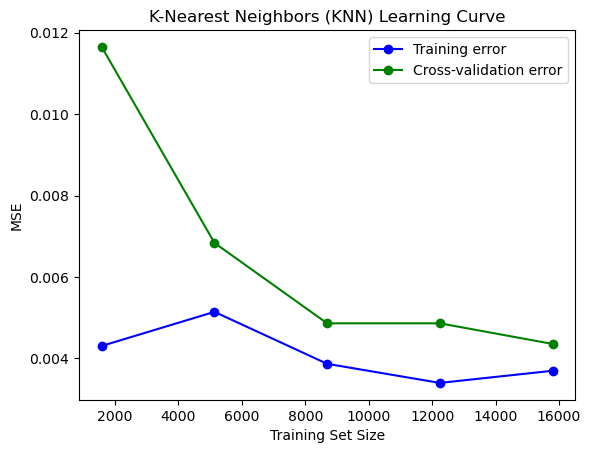

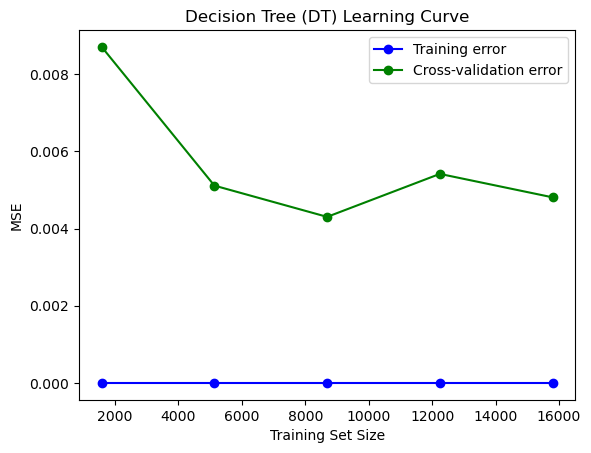

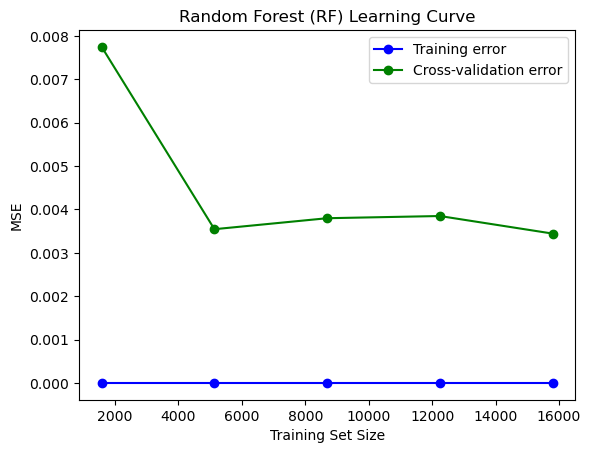

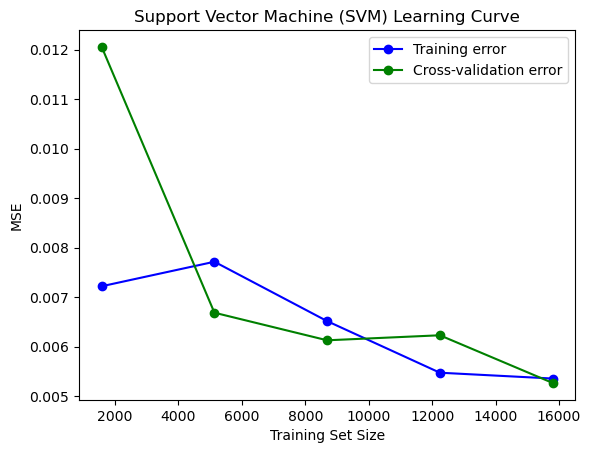

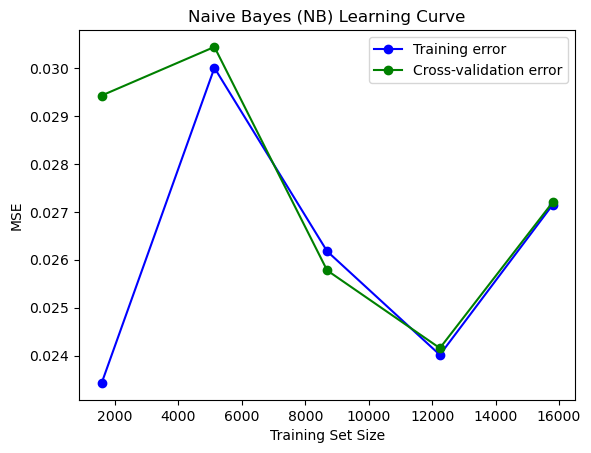

In [32]:
# Looping untuk mean squared error (MSE) setiap model
for model_name, model in models.items():
    train_sizes, train_scores, test_scores = learning_curve(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
 
    # Menghitung rata-rata dan standar deviasi
    train_mean = -np.mean(train_scores, axis=1)
    test_mean = -np.mean(test_scores, axis=1)
    
    # Plot learning curve
    plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training error")
    plt.plot(train_sizes, test_mean, 'o-', color="green", label="Cross-validation error")
    plt.title(f'{model_name} Learning Curve')
    plt.xlabel("Training Set Size")
    plt.ylabel("MSE")
    plt.legend()
    plt.show()

## **c. Tuning Model Klasifikasi (Optional)**

Gunakan GridSearchCV, RandomizedSearchCV, atau metode lainnya untuk mencari kombinasi hyperparameter terbaik

In [ ]:
#Type your code here

## **d. Evaluasi Model Klasifikasi setelah Tuning (Optional)**

Berikut adalah rekomendasi tahapannya.
1. Gunakan model dengan hyperparameter terbaik.
2. Hitung ulang metrik evaluasi untuk melihat apakah ada peningkatan performa.

In [ ]:
#Type your code here

## **e. Analisis Hasil Evaluasi Model Klasifikasi**

Berikut adalah **rekomendasi** tahapannya.
1. Bandingkan hasil evaluasi sebelum dan setelah tuning (jika dilakukan).
2. Identifikasi kelemahan model, seperti:
  - Precision atau Recall rendah untuk kelas tertentu.
  - Apakah model mengalami overfitting atau underfitting?
3. Berikan rekomendasi tindakan lanjutan, seperti mengumpulkan data tambahan atau mencoba algoritma lain jika hasil belum memuaskan.

### **Model K-Nearest Neighbors (KNN):**  
- **Hasil evaluasi:**  
    a. *Accuracy:* 0.998177  
    b. *Precision:* Sangat tinggi (mendekati 1) pada semua kelas.  
    c. *Recall:* Konsisten tinggi untuk semua kelas.  
    d. *F1-Score:* Seimbang antara precision dan recall.  
- **Hasil Confusion Matrix:**  
  ```
  [[3008    0    2]  
   [   3 1702    1]  
   [   3    0  218]]  
  ```
  - **Kelas 1 (label pertama):**  
    - **Benar diprediksi sebagai kelas 1** sebanyak **3008 kali**.  
    - **Salah diprediksi sebagai kelas 3** sebanyak **2 kali**.  
  - **Kelas 2 (label kedua):**  
    - **Benar diprediksi sebagai kelas 2** sebanyak **1702 kali**.  
    - **Salah diprediksi sebagai kelas 1** sebanyak **3 kali**.  
    - **Salah diprediksi sebagai kelas 3** sebanyak **1 kali**.  
  - **Kelas 3 (label ketiga):**  
    - **Benar diprediksi sebagai kelas 3** sebanyak **218 kali**.  
    - **Salah diprediksi sebagai kelas 1** sebanyak **3 kali**.  
  - Kesalahan prediksi **sangat minim**, menunjukkan model ini sangat akurat.  
- **Hasil MSE:**  
  - Training MSE: 0.0037  
  - Test MSE: 0.0048  
  - **Model ini cukup baik dalam generalisasi, tanpa indikasi overfitting atau underfitting.**  
- **Hasil Learning Curve:** 
  - Tidak overfitting, karena tidak ada gap besar antara training dan validation error. 
  - Tidak underfitting, karena error validasi terus menurun seiring bertambahnya data.  



### **Model Decision Tree (DT):**  
- **Hasil evaluasi:**  
    a. *Accuracy:* 0.998785  
    b. *Precision:* Sangat tinggi, hampir 1 di semua kelas.  
    c. *Recall:* Sangat tinggi, hampir sempurna.  
    d. *F1-Score:* Seimbang di semua kelas.  
- **Hasil Confusion Matrix:**  
  ```
  [[3006    2    2]  
   [   0 1705    1]  
   [   1    0  220]]  
  ```
  - **Kelas 1:** Salah prediksi **hanya 4 kali** (2 ke kelas 2, 2 ke kelas 3).  
  - **Kelas 2:** Salah prediksi **hanya 1 kali** ke kelas 3.  
  - **Kelas 3:** Salah prediksi **hanya 1 kali** ke kelas 1.  
  - Kesalahan prediksi sangat kecil, menunjukkan performa yang hampir sempurna.  
- **Hasil MSE:**  
  - Training MSE: 0.0  
  - Test MSE: 0.0030  
  - **Model mengalami overfitting** karena training error = 0, menunjukkan model terlalu menghafal data.  
- **Hasil Learning Curve:**  
  Overfitting kuat, karena model bekerja sangat baik pada data pelatihan, tetapi buruk pada data validasi.



### **Model Random Forest (RF):**  
- **Hasil evaluasi:**  
    a. *Accuracy:* 0.998785  
    b. *Precision:* Sangat tinggi di semua kelas.  
    c. *Recall:* Sangat baik, mirip dengan Decision Tree.  
    d. *F1-Score:* Seimbang antara precision dan recall.  
- **Hasil Confusion Matrix:**  
  ```
  [[3007    1    2]  
   [   1 1704    1]  
   [   1    0  220]]  
  ```
  - **Kelas 1:** Salah prediksi **3 kali** (1 ke kelas 2, 2 ke kelas 3).  
  - **Kelas 2:** Salah prediksi **2 kali** (1 ke kelas 1, 1 ke kelas 3).  
  - **Kelas 3:** Salah prediksi **1 kali** ke kelas 1.  
  - Kesalahan prediksi sedikit lebih kecil dibanding Decision Tree.  
- **Hasil MSE:**  
  - Training MSE: 0.0  
  - Test MSE: 0.0030  
  - **Overfitting parah** karena training error = 0.  
- **Hasil Learning Curve:**  
  - Tidak overfitting, karena error validasi tetap stabil.
  - Tidak underfitting, karena model menunjukkan performa yang baik.



### **Model Support Vector Machine (SVM):**  
- **Hasil evaluasi:**  
    a. *Accuracy:* 0.997367  
    b. *Precision:* Sangat tinggi, terutama untuk kelas mayoritas.  
    c. *Recall:* Cukup baik, tetapi ada sedikit penurunan pada kelas minoritas.  
    d. *F1-Score:* Masih cukup seimbang, tetapi kurang optimal dibanding model lain.  
- **Hasil Confusion Matrix:**  
  ```
  [[3008    0    2]  
   [   3 1702    1]  
   [   7    0  214]]  
  ```
  - **Kelas 1:** Salah prediksi **2 kali** ke kelas 3.  
  - **Kelas 2:** Salah prediksi **4 kali** (3 ke kelas 1, 1 ke kelas 3).  
  - **Kelas 3:** Salah prediksi **7 kali** ke kelas 1.  
  - Kesalahan prediksi lebih tinggi dibanding model lain.  
- **Hasil MSE:**  
  - Training MSE: 0.0053  
  - Test MSE: 0.0081  
  - **Overfitting sedang** karena selisih error antara training dan test cukup besar.  
- **Hasil Learning Curve:**  
  - Tidak ada overfitting, karena training dan validation error hampir sejajar pada ukuran data besar.
  - Tidak ada underfitting, karena kedua error mencapai nilai rendah.  



### **Model Naive Bayes (NB):**  
- **Hasil evaluasi:**  
    a. *Accuracy:* 0.988049  
    b. *Precision:* Relatif tinggi, tetapi lebih rendah di kelas tertentu.  
    c. *Recall:* Kurang optimal, terutama di kelas minoritas.  
    d. *F1-Score:* Kurang baik dibanding model lain.  
- **Hasil Confusion Matrix:**  
  ```
  [[2969    0   41]  
   [  12 1693    1]  
   [   5    0  216]]  
  ```
  - **Kelas 1:** Salah prediksi **41 kali** ke kelas 3.  
  - **Kelas 2:** Salah prediksi **13 kali** (12 ke kelas 1, 1 ke kelas 3).  
  - **Kelas 3:** Salah prediksi **5 kali** ke kelas 1.  
  - **Model mengalami kesulitan dalam membedakan kelas 1 dan 3**.  
- **Hasil MSE:**  
  - Training MSE: 0.0288  
  - Test MSE: 0.0399  
  - **Underfitting (test error tinggi, training error juga tinggi).**  
- **Hasil Learning Curve:**  
  - Tidak overfitting, karena gap antara training dan validation error kecil.
  - Tidak underfitting, karena error pelatihan dan validasi tetap rendah. 

# Kesimpulan
- KNN & Random Forest -> Model yang paling stabil tanpa indikasi overfitting atau underfitting.
- Decision Tree -> Overfitting parah, perlu pruning atau regularisasi.
- SVM -> Performa baik, tapi perlu tuning lebih lanjut.
- Naive Bayes -> Model cukup stabil, tapi bisa ditingkatkan dengan preprocessing yang lebih baik.